In [1]:
#!/usr/bin/env python3
# -*- coding: utf-8 -*-
"""
Created on Wed Dec  6 16:19:57 2023

@author: mnarang
"""
import numpy as np

import matplotlib.pyplot as plt
import pandas as pd
from astropy.io import fits
from astropy.convolution import convolve, Gaussian2DKernel
import astropy.convolution  as convolution
from astropy.wcs import WCS
from reproject import reproject_interp

import matplotlib.pyplot as plt
from astropy.io import fits
from astropy.wcs import WCS
from mpl_toolkits.axes_grid1 import make_axes_locatable
import numpy as np
from matplotlib.colors import LogNorm
import matplotlib.gridspec as gridspec
from astropy.visualization.wcsaxes import SphericalCircle
from astropy.wcs.utils import skycoord_to_pixel
from astropy.coordinates import SkyCoord
import astropy.units as u
import aplpy
plt.rcParams['font.size'] = 35
plt.rcParams['axes.labelsize'] = 35
plt.rcParams['xtick.labelsize'] = 35
plt.rcParams['ytick.labelsize'] = 35
plt.rcParams['legend.fontsize'] = 35
plt.rcParams['figure.titlesize'] = 35
plt.rcParams['axes.labelweight'] = 'heavy'
plt.rcParams['axes.linewidth'] = 3
plt.rcParams['xtick.major.size'] = 20
plt.rcParams['xtick.minor.size'] = 8
plt.rcParams['ytick.major.size'] = 20
plt.rcParams['ytick.minor.size'] = 8
plt.rcParams["contour.linewidth"] =5


RA=247.09010762  
Dec=-24.60669595 #JWST

def Angular_resolution(wave):
    return (0.033*wave) + 0.106
    

In [36]:
Angular_resolution(5.34)

0.28222

In [3]:


def Match_Angular_Resolution(input_file, input_wavelength, 
                             hdu_idx=0, 
                             target_Resolution=None, 
                             target_wavelength=None,
                             Save_FITS=True,
                             ):
    """
    Degrade the Resolution of the JWST IFU images assuming gaussian beams.

    input_file: FITS to degrade
    input_wavelength: wavelength of input image
    hdu_idx: index of hdu that contains data
    target_Resolution: Desired Resolution in arcsec
    target_wavelength: Wavelength of the Desired Resolution 
    Save_FITS: Saves smoothed image as FITS image
    """

    high_res_file = input_file

    hdu = fits.open(high_res_file)[hdu_idx]
    hdr = hdu.header
    px_scale = np.abs(hdr['CDELT1'])*3600

    high_res_data = hdu.data

    high_Resolution = Angular_resolution(input_wavelength)

    if target_Resolution==None:
        target_Resolution = Angular_resolution(target_wavelength)
    elif target_Resolution<high_Resolution:
        raise IOError(f"Careful with the inputs! Can't sharpen the images")
    
    high_res_sigma_pixel = high_Resolution/px_scale/(2.0 * np.sqrt(2.0 * np.log(2.0)))
    target_res_sigma_pixels = target_Resolution/px_scale/(2.0 * np.sqrt(2.0 * np.log(2.0)))

    kernel_fwhm_pixels = np.sqrt(target_Resolution**2 - high_Resolution**2)/px_scale
    kernel_sigma_pixels = kernel_fwhm_pixels / (2.0 * np.sqrt(2.0 * np.log(2.0)))

    kernel = convolution.Gaussian2DKernel(kernel_sigma_pixels, kernel_sigma_pixels)
    smoothed_image = convolution.convolve(high_res_data, kernel, preserve_nan=True, normalize_kernel=True)

    if Save_FITS:
        hdu = fits.PrimaryHDU()
        hdu.data = smoothed_image #/px_area17
        if hdu_idx==0:
            hdu.header = hdr
        else:
            # hdu.header = wcs.WCS(hdr)
            pass
        print(hdu)
        hdu.writeto(f"{input_file[:-5]}Res{target_Resolution}_conv.fits", overwrite=True)

    return smoothed_image


In [4]:

s11=Match_Angular_Resolution('./I16253_lineimages/H200S11_4.18_linemap.fits', 4.18,  hdu_idx=0,  target_wavelength=17.033)

s2=Match_Angular_Resolution('./I16253_lineimages/H200S2_12.279_linemap.fits', 12.279,  hdu_idx=0,  target_wavelength=17.033)
s3=Match_Angular_Resolution('./I16253_lineimages/H200S3_9.6649_linemap.fits', 9.6649,  hdu_idx=0,  target_wavelength=17.033)
s4=Match_Angular_Resolution('./I16253_lineimages/H200S4_8.025_linemap.fits', 8.025,  hdu_idx=0,  target_wavelength=17.033)
s5=Match_Angular_Resolution('./I16253_lineimages/H200S5_6.9095_linemap.fits', 6.9095,  hdu_idx=0,  target_wavelength=17.033)
s7=Match_Angular_Resolution('./I16253_lineimages/H200S7_5.5115_linemap.fits', 5.5115,  hdu_idx=0,  target_wavelength=17.033)


the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.965746 from OBSGEO-[XYZ].
Set OBSGEO-H to 1726065897.713 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.845749 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724348320.928 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


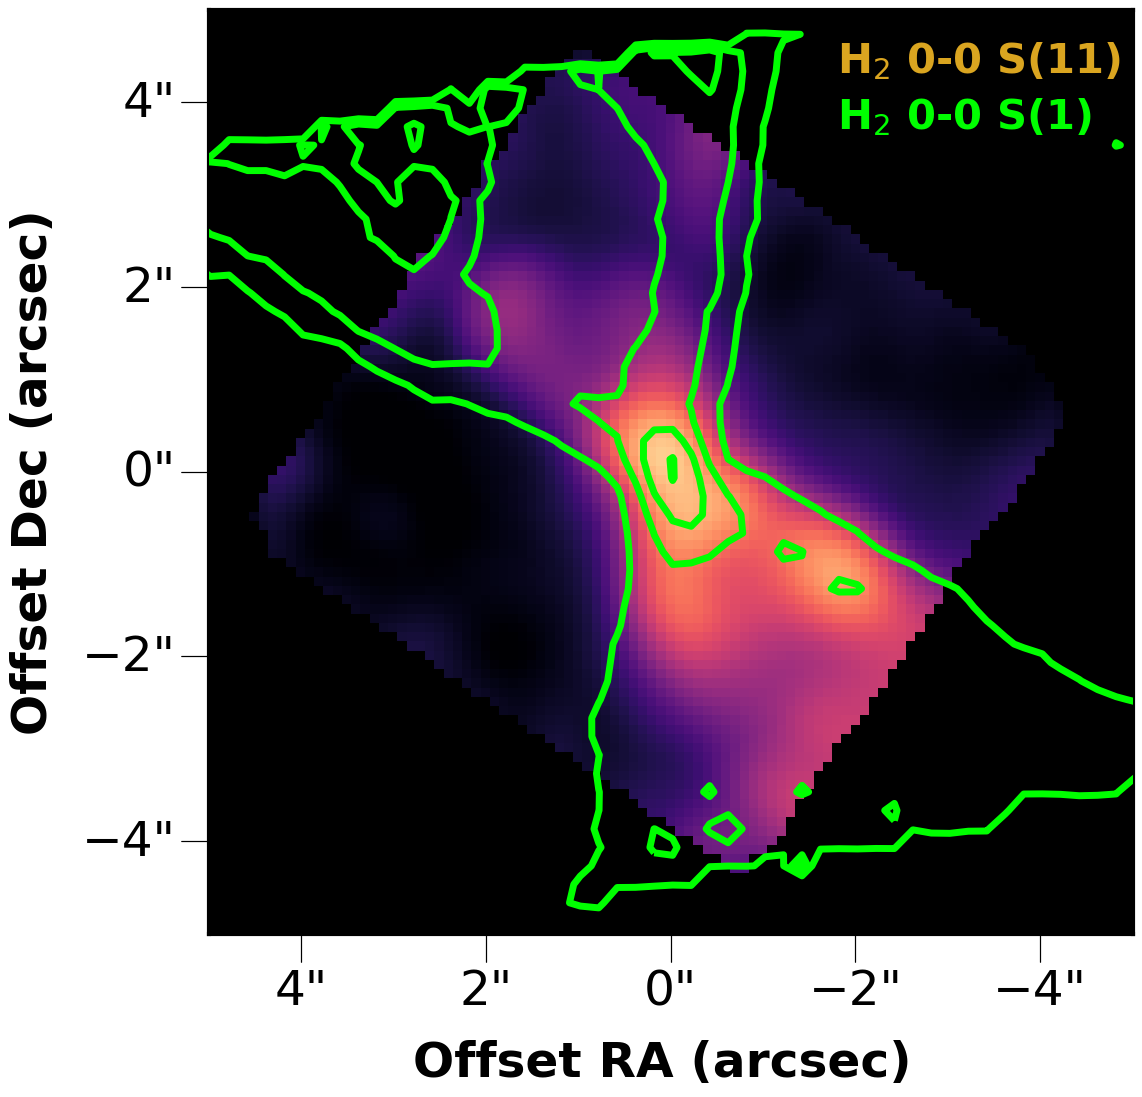

In [5]:
plt.rcParams["contour.linewidth"] =5
plt.rcParams['axes.facecolor'] = 'black'
hdu2 = fits.open('./I16253_lineimages/H200S1_17.033_linemap.fits')[0]
hdu1 = fits.open('./I16253_lineimages/H200S11_4.18_linemapRes0.668089_conv.fits')[0]

# Extract the data arrays and WCS objects from the HDUs
data1 = hdu1.data
wcs1 = WCS(hdu1.header)
data2 = hdu2.data
wcs2 = WCS(hdu2.header)
ps=hdu1.header['CDELT1']*3600

sky=SkyCoord(RA, Dec, unit="deg")

xa, ya = wcs1.world_to_pixel(sky) 


v1=5e-7
v2=3e-5

region_center = SkyCoord(RA, Dec, unit=u.deg, frame='icrs' )

fig = plt.figure(figsize=[12, 12])

proj = WCS(hdu1.header)
ax = fig.add_subplot(111, projection=proj)

data2=np.array(data2)
data2=np.nan_to_num(data2)

im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1, vmin=np.log10(v1),vmax=np.log10(v2))
ax.contour(data2,transform=ax.get_transform(wcs2),levels=np.max(data2)*np.array([0.4,0.6,0.8,0.99]),colors='lime')




# Remove the absolute coordinates
ra = ax.coords["ra"]
dec = ax.coords["dec"]
ra.set_ticks_visible(False)
ra.set_ticklabel_visible(False)
dec.set_ticks_visible(False)
dec.set_ticklabel_visible(False)
ra.set_axislabel("")
dec.set_axislabel("")

# Create an overlay with relative coordinates
aframe = region_center.skyoffset_frame()
overlay = ax.get_coords_overlay(aframe)
ra_offset = overlay["lon"]
dec_offset = overlay["lat"]



dec_offset.set_axislabel(f"Offset Dec (arcsec)")
ra_offset.set_axislabel("Offset RA (arcsec) ")

ax.text(65,88,'H$_2$ 0-0 S(11)',color='goldenrod',size=30,weight='heavy')
ax.text(65,82,'H$_2$ 0-0 S(1)',color='lime',size=30,weight='heavy')

ra_offset.set_major_formatter("s")
dec_offset.set_major_formatter("s")
ra_offset.set_ticks_position("b")
ra_offset.set_ticklabel_position("b")
dec_offset.set_ticks_position("l")
dec_offset.set_ticklabel_position("l")
ra_offset.set_axislabel_position("b")
dec_offset.set_axislabel_position("l")
#ra_offset.coord_wrap = 180
plt.ylim(ya-(5/np.abs(ps)),ya+(5/np.abs(ps)))
plt.xlim(xa-(5/np.abs(ps)),xa+(5/np.abs(ps)))
# ra_offset.coord_wrap = 180 # avoid wrapping
plt.savefig('Figure6a.png',bbox_inches='tight')

In [6]:
np.max(data2)

7.763249666869645e-06

Set OBSGEO-B to   -36.845749 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724348320.928 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]


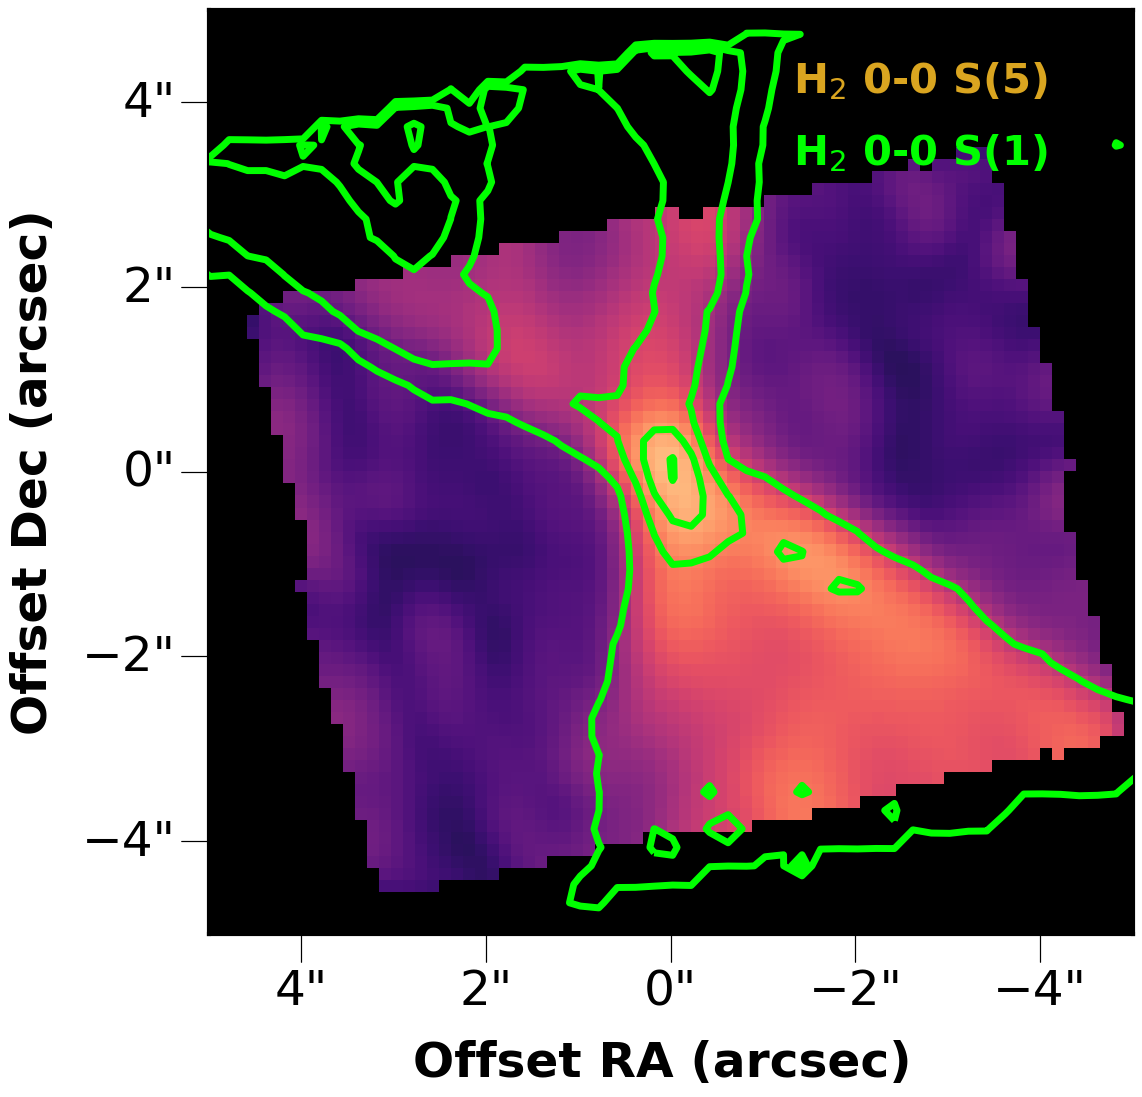

In [7]:


hdu2 = fits.open('./I16253_lineimages/H200S1_17.033_linemap.fits')[0]
hdu1 = fits.open('./I16253_lineimages/H200S5_6.9095_linemapRes0.668089_conv.fits')[0]

# Extract the data arrays and WCS objects from the HDUs
data1 = hdu1.data
wcs1 = WCS(hdu1.header)
data2 = hdu2.data
wcs2 = WCS(hdu2.header)
ps=hdu1.header['CDELT1']*3600



sky=SkyCoord(RA, Dec, unit="deg")

xa, ya = wcs1.world_to_pixel(sky) 


v1=9e-7
v2=1e-4

region_center = SkyCoord(RA, Dec, unit=u.deg, frame='icrs' )

fig = plt.figure(figsize=[12, 12])

proj = WCS(hdu1.header)
ax = fig.add_subplot(111, projection=proj)

data2=np.array(data2)
data2=np.nan_to_num(data2)

im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1, vmin=np.log10(v1),vmax=np.log10(v2))
ax.contour(data2,transform=ax.get_transform(wcs2),levels=np.max(data2)*np.array([0.4,0.6,0.8,0.99]),colors='lime')




# Remove the absolute coordinates
ra = ax.coords["ra"]
dec = ax.coords["dec"]
ra.set_ticks_visible(False)
ra.set_ticklabel_visible(False)
dec.set_ticks_visible(False)
dec.set_ticklabel_visible(False)
ra.set_axislabel("")
dec.set_axislabel("")

# Create an overlay with relative coordinates
aframe = region_center.skyoffset_frame()
overlay = ax.get_coords_overlay(aframe)
ra_offset = overlay["lon"]
dec_offset = overlay["lat"]

ax.text(46,68,'H$_2$ 0-0 S(5)',color='goldenrod',size=30,weight='heavy')
ax.text(46,62,'H$_2$ 0-0 S(1)',color='lime',size=30,weight='heavy')

dec_offset.set_axislabel(f"Offset Dec (arcsec)")
ra_offset.set_axislabel("Offset RA (arcsec) ")

ra_offset.set_major_formatter("s")
dec_offset.set_major_formatter("s")
ra_offset.set_ticks_position("b")
ra_offset.set_ticklabel_position("b")
dec_offset.set_ticks_position("l")
dec_offset.set_ticklabel_position("l")
ra_offset.set_axislabel_position("b")
dec_offset.set_axislabel_position("l")
#ra_offset.coord_wrap = 180
plt.ylim(ya-(5/np.abs(ps)),ya+(5/np.abs(ps)))
plt.xlim(xa-(5/np.abs(ps)),xa+(5/np.abs(ps)))
#ra_offset.coord_wrap = 180 # avoid wrapping
plt.savefig('Figure6b.png',bbox_inches='tight')

In [8]:
np.max(data2)

7.763249666869645e-06

<>:82: SyntaxWarning: invalid escape sequence '\m'
<>:82: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89419/894286390.py:82: SyntaxWarning: invalid escape sequence '\m'
  ax.text(43,63,'Cont @ 4.17 $\mu$m',color='lime',size=30,weight='heavy')
Set OBSGEO-B to   -36.845749 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724348320.928 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.965746 from OBSGEO-[XYZ].
Set OBSGEO-H to 1726065897.713 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89419/894286390.py:38: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1,


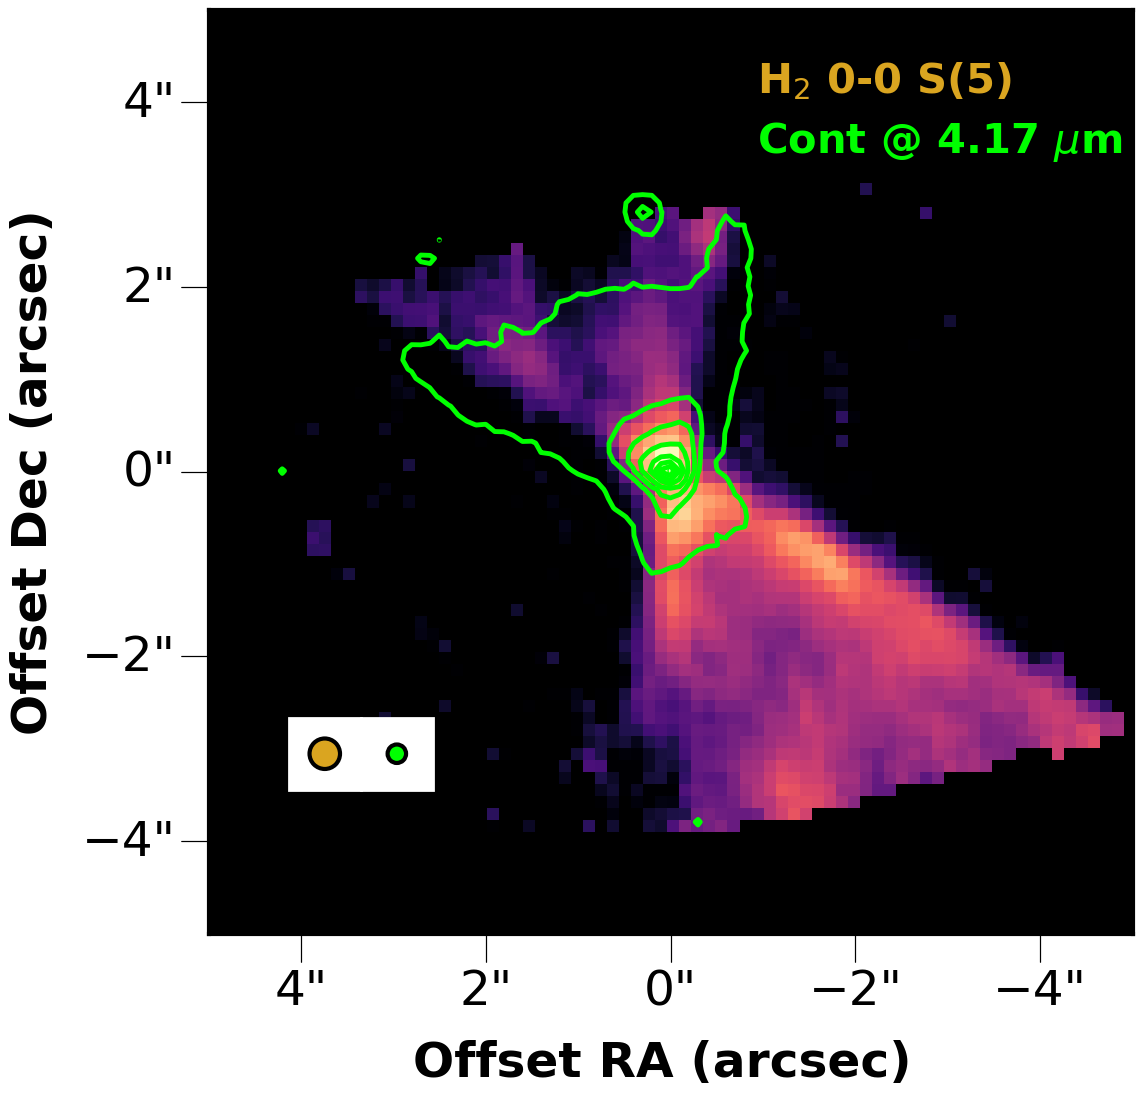

In [9]:
from matplotlib.patches import Rectangle, Circle
plt.rcParams["contour.linewidth"] =3.5
hdu2 = fits.open('cont_41.fits')[0]
hdu1 = fits.open('./I16253_lineimages/H200S5_6.9095_linemap.fits')[0]
hdu1a= fits.open('./I16253_lineimages/H200S5_6.9095_error.fits')[0]

# Extract the data arrays and WCS objects from the HDUs
data1 = hdu1.data
wcs1 = WCS(hdu1.header)
data2 = hdu2.data

data1a = hdu1a.data


data1[data1/data1a<5]=0

wcs2 = WCS(hdu2.header)
ps=hdu1.header['CDELT1']*3600

sky=SkyCoord(RA, Dec, unit="deg")

xa, ya = wcs1.world_to_pixel(sky) 


v1=5e-6
v2=9e-5

region_center = SkyCoord(RA, Dec, unit=u.deg, frame='icrs' )

fig = plt.figure(figsize=[12, 12])

proj = WCS(hdu1.header)
ax = fig.add_subplot(111, projection=proj)

data2=np.array(data2)
data2=np.nan_to_num(data2)

im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1,
                  vmin=np.log10(v1),vmax=np.log10(v2))


ax.contour(data2,transform=ax.get_transform(wcs2),levels=np.max(data2)*np.array([0.01,0.05,0.1,0.2,0.4,0.6,0.8,0.99]),colors='lime')



# Remove the absolute coordinates
ra = ax.coords["ra"]
dec = ax.coords["dec"]
ra.set_ticks_visible(False)
ra.set_ticklabel_visible(False)
dec.set_ticks_visible(False)
dec.set_ticklabel_visible(False)
ra.set_axislabel("")
dec.set_axislabel("")

# Create an overlay with relative coordinates
aframe = region_center.skyoffset_frame()
overlay = ax.get_coords_overlay(aframe)
ra_offset = overlay["lon"]
dec_offset = overlay["lat"]

x0, y0 = 10, 10  # example position, change as needed
rect = Rectangle((x0, y0), 6, 6, edgecolor='white', facecolor='white', lw=2)
ax.add_patch(rect)

x0, y0 = 4, 10  # example position, change as needed
rect = Rectangle((x0, y0), 6, 6, edgecolor='white', facecolor='white', lw=2)
ax.add_patch(rect)

# Add a circle of radius 0.13/np.abs(ps) at center (cx, cy)
cx, cy = 13, 13  # example center, change as needed
radius = 0.2 / (2* np.abs(ps))
circ = Circle((cx, cy), radius, edgecolor='k', facecolor='lime', lw=3,zorder=11)
ax.add_patch(circ,)

cx, cy = 7, 13  # example center, change as needed
radius = 0.33 / (2* np.abs(ps))
circ = Circle((cx, cy), radius, edgecolor='k', facecolor='goldenrod', lw=3,zorder=11)
ax.add_patch(circ,)

ax.text(43,68,'H$_2$ 0-0 S(5)',color='goldenrod',size=30,weight='heavy')
ax.text(43,63,'Cont @ 4.17 $\mu$m',color='lime',size=30,weight='heavy')

dec_offset.set_axislabel(f"Offset Dec (arcsec)")
ra_offset.set_axislabel("Offset RA (arcsec) ")

ra_offset.set_major_formatter("s")
dec_offset.set_major_formatter("s")
ra_offset.set_ticks_position("b")
ra_offset.set_ticklabel_position("b")
dec_offset.set_ticks_position("l")
dec_offset.set_ticklabel_position("l")
ra_offset.set_axislabel_position("b")
dec_offset.set_axislabel_position("l")
#ra_offset.coord_wrap = 180
plt.ylim(ya-(5/np.abs(ps)),ya+(5/np.abs(ps)))
plt.xlim(xa-(5/np.abs(ps)),xa+(5/np.abs(ps)))
# ra_offset.coord_wrap = 180 # avoid wrapping
plt.savefig('Figure7b.png',bbox_inches='tight')

In [10]:
np.max(data2)

2.087247

<>:79: SyntaxWarning: invalid escape sequence '\m'
<>:79: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89419/2320278549.py:79: SyntaxWarning: invalid escape sequence '\m'
  ax.text(57,78,'Cont @ 4.17 $\mu$m',color='lime',size=30,weight='heavy')
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.965746 from OBSGEO-[XYZ].
Set OBSGEO-H to 1726065897.713 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89419/2320278549.py:35: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1,


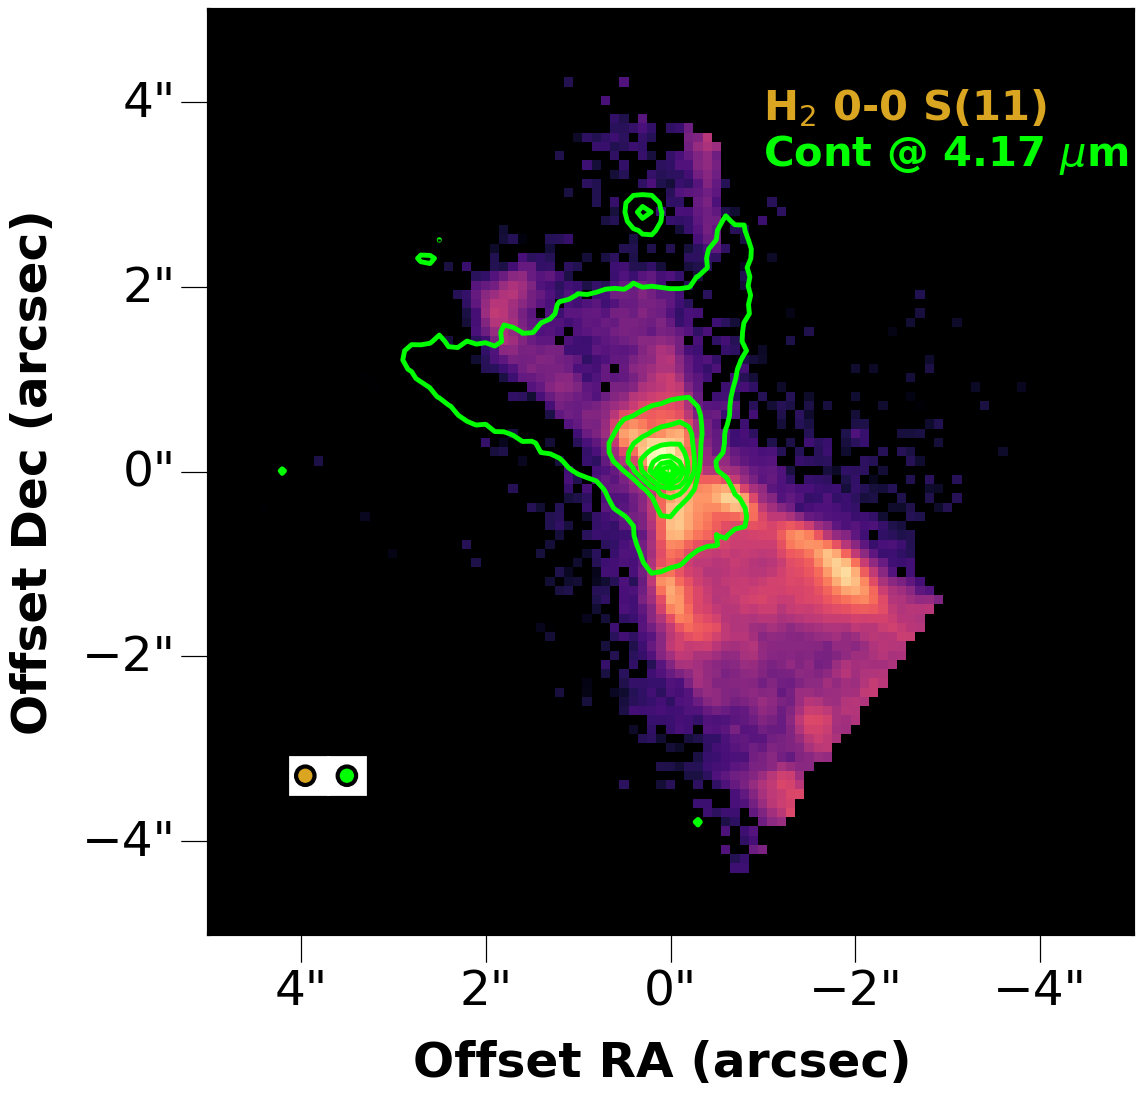

In [11]:


hdu2 = fits.open('cont_41.fits')[0]
hdu1 = fits.open('./I16253_lineimages/H200S11_4.18_linemap.fits')[0]


# Extract the data arrays and WCS objects from the HDUs
data1 = hdu1.data
wcs1 = WCS(hdu1.header)
data2 = hdu2.data
wcs2 = WCS(hdu2.header)
ps=hdu1.header['CDELT1']*3600

hdu1a = fits.open('./I16253_lineimages/H200S11_4.18_error.fits')[0]
data1a = hdu1a.data


data1[data1/data1a<5]=0

sky=SkyCoord(RA, Dec, unit="deg")

xa, ya = wcs1.world_to_pixel(sky) 

v1=5e-7
v2=5e-5

region_center = SkyCoord(RA, Dec, unit=u.deg, frame='icrs' )

fig = plt.figure(figsize=[12, 12])

proj = WCS(hdu1.header)
ax = fig.add_subplot(111, projection=proj)

data2=np.array(data2)
data2=np.nan_to_num(data2)

im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1,
                  vmin=np.log10(v1),vmax=np.log10(v2))


ax.contour(data2,transform=ax.get_transform(wcs2),levels=np.max(data2)*np.array([0.01,0.05,0.1,0.2,0.4,0.6,0.8,0.99]),colors='lime')


# Remove the absolute coordinates
ra = ax.coords["ra"]
dec = ax.coords["dec"]
ra.set_ticks_visible(False)
ra.set_ticklabel_visible(False)
dec.set_ticks_visible(False)
dec.set_ticklabel_visible(False)
ra.set_axislabel("")
dec.set_axislabel("")

# Create an overlay with relative coordinates
aframe = region_center.skyoffset_frame()
overlay = ax.get_coords_overlay(aframe)
ra_offset = overlay["lon"]
dec_offset = overlay["lat"]


x0, y0 = 10, 10  # example position, change as needed
rect = Rectangle((x0, y0), 4, 4, edgecolor='white', facecolor='white', lw=2)
ax.add_patch(rect)

x0, y0 = 5.8, 10  # example position, change as needed
rect = Rectangle((x0, y0), 4.2, 4, edgecolor='white', facecolor='white', lw=2)
ax.add_patch(rect)

# Add a circle of radius 0.13/np.abs(ps) at center (cx, cy)
cx, cy = 12, 12  # example center, change as needed
radius = 0.2 / (2* np.abs(ps))
circ = Circle((cx, cy), radius, edgecolor='k', facecolor='lime', lw=3,zorder=11)
ax.add_patch(circ,)

cx, cy = 7.5, 12  # example center, change as needed
radius = 0.2 /(2* np.abs(ps))
circ = Circle((cx, cy), radius,  edgecolor='k', facecolor='goldenrod', lw=3,zorder=11)
ax.add_patch(circ,)

ax.text(57,83,'H$_2$ 0-0 S(11)',color='goldenrod',size=30,weight='heavy')
ax.text(57,78,'Cont @ 4.17 $\mu$m',color='lime',size=30,weight='heavy')

dec_offset.set_axislabel(f"Offset Dec (arcsec)")
ra_offset.set_axislabel("Offset RA (arcsec) ")

ra_offset.set_major_formatter("s")
dec_offset.set_major_formatter("s")
ra_offset.set_ticks_position("b")
ra_offset.set_ticklabel_position("b")
dec_offset.set_ticks_position("l")
dec_offset.set_ticklabel_position("l")
ra_offset.set_axislabel_position("b")
dec_offset.set_axislabel_position("l")
#ra_offset.coord_wrap = 180
plt.ylim(ya-(5/np.abs(ps)),ya+(5/np.abs(ps)))
plt.xlim(xa-(5/np.abs(ps)),xa+(5/np.abs(ps)))
# ra_offset.coord_wrap = 180 # avoid wrapping
plt.savefig('Figure7a.png',bbox_inches='tight')

In [12]:
np.max(data2)

2.087247

<>:81: SyntaxWarning: invalid escape sequence '\m'
<>:81: SyntaxWarning: invalid escape sequence '\m'
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89419/4348016.py:81: SyntaxWarning: invalid escape sequence '\m'
  ax.text(34,45,'Cont @ 4.17 $\mu$m',color='lime',size=30,weight='heavy')
Set OBSGEO-B to   -36.845749 from OBSGEO-[XYZ].
Set OBSGEO-H to 1724348320.928 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
the RADECSYS keyword is deprecated, use RADESYSa. [astropy.wcs.wcs]
Set OBSGEO-B to   -36.965746 from OBSGEO-[XYZ].
Set OBSGEO-H to 1726065897.713 from OBSGEO-[XYZ]'. [astropy.wcs.wcs]
/var/folders/lr/j2hz1s0d0pn69_gzyyfbcdm00000gq/T/ipykernel_89419/4348016.py:35: RuntimeWarning: divide by zero encountered in log10
  im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1,


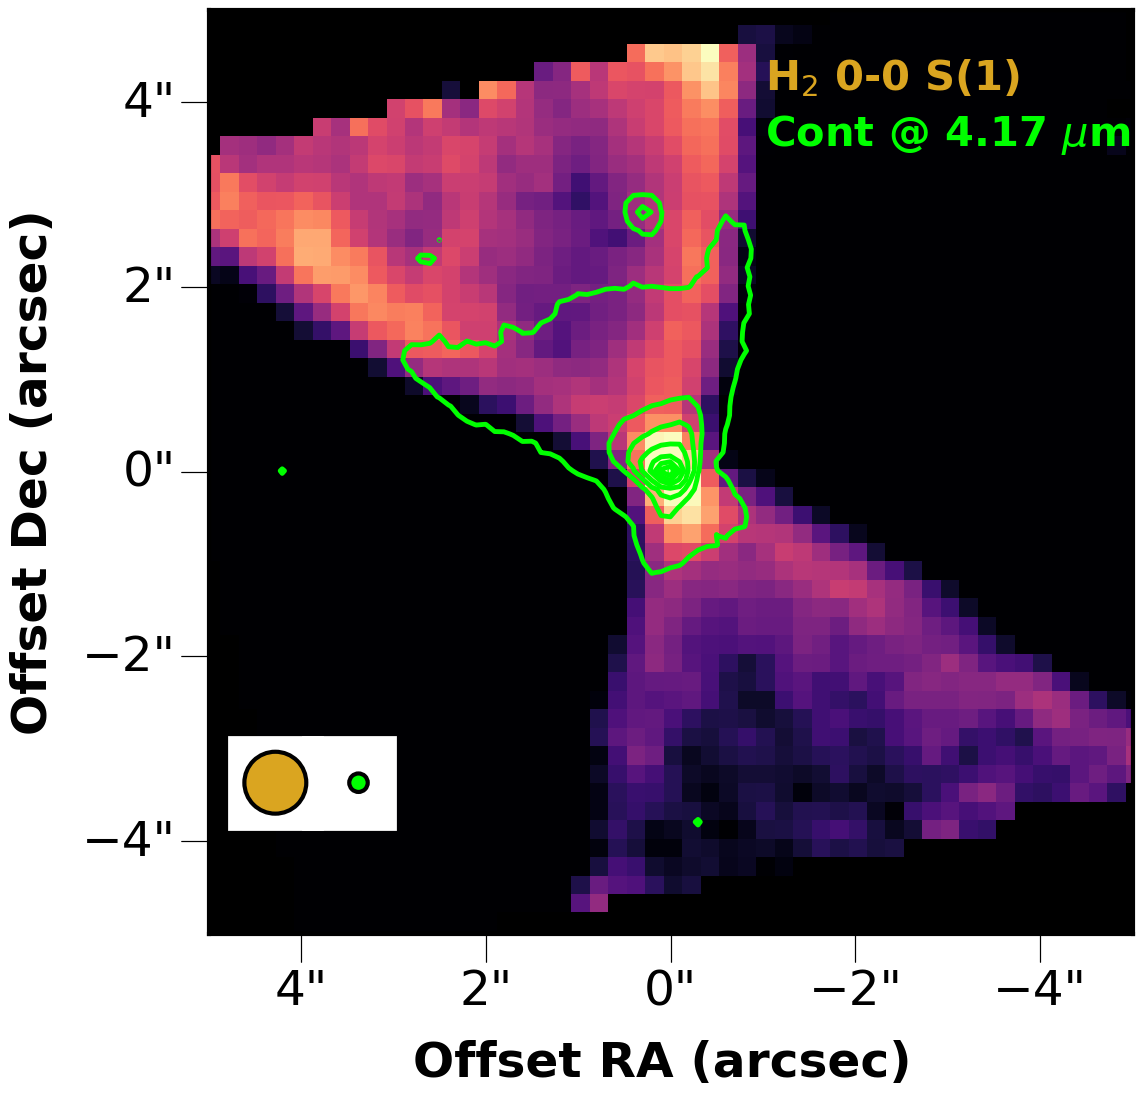

In [13]:


hdu2 = fits.open('cont_41.fits')[0]
hdu1 = fits.open('./I16253_lineimages/H200S1_17.033_linemap.fits')[0]

# Extract the data arrays and WCS objects from the HDUs
data1 = hdu1.data
wcs1 = WCS(hdu1.header)
data2 = hdu2.data
wcs2 = WCS(hdu2.header)
ps=hdu1.header['CDELT1']*3600

hdu1a = fits.open('./I16253_lineimages/H200S1_17.033_error.fits')[0]
data1a = hdu1a.data


data1[data1/data1a<5]=0

sky=SkyCoord(RA, Dec, unit="deg")

xa, ya = wcs1.world_to_pixel(sky) 


v1=3e-6
v2=7e-6

region_center = SkyCoord(RA, Dec, unit=u.deg, frame='icrs' )

fig = plt.figure(figsize=[12, 12])

proj = WCS(hdu1.header)
ax = fig.add_subplot(111, projection=proj)

data2=np.array(data2)
data2=np.nan_to_num(data2)

im = ax.imshow(np.log10(data1), origin='lower',cmap='magma',alpha=1,
                  vmin=np.log10(v1),vmax=np.log10(v2))


ax.contour(data2,transform=ax.get_transform(wcs2),levels=np.max(data2)*np.array([0.01,0.05,0.1,0.2,0.4,0.6,0.8,0.99]),colors='lime')



# Remove the absolute coordinates
ra = ax.coords["ra"]
dec = ax.coords["dec"]
ra.set_ticks_visible(False)
ra.set_ticklabel_visible(False)
dec.set_ticks_visible(False)
dec.set_ticklabel_visible(False)
ra.set_axislabel("")
dec.set_axislabel("")

# Create an overlay with relative coordinates
aframe = region_center.skyoffset_frame()
overlay = ax.get_coords_overlay(aframe)
ra_offset = overlay["lon"]
dec_offset = overlay["lat"]


x0, y0 = 9, 8  # example position, change as needed
rect = Rectangle((x0, y0), 5, 5, edgecolor='white', facecolor='white', lw=2)
ax.add_patch(rect)

x0, y0 = 5, 8  # example position, change as needed
rect = Rectangle((x0, y0), 5, 5, edgecolor='white', facecolor='white', lw=2)
ax.add_patch(rect)

# Add a circle of radius 0.13/np.abs(ps) at center (cx, cy)
cx, cy = 12, 10.5  # example center, change as needed
radius = 0.2 /(2* np.abs(ps))
circ = Circle((cx, cy), radius, edgecolor='k', facecolor='lime', lw=3,zorder=11)
ax.add_patch(circ,)

cx, cy = 7.5, 10.5  # example center, change as needed
radius = 0.67 / (2* np.abs(ps))
circ = Circle((cx, cy), radius,  edgecolor='k', facecolor='goldenrod', lw=3,zorder=11)
ax.add_patch(circ,)


ax.text(34,48,'H$_2$ 0-0 S(1)',color='goldenrod',size=30,weight='heavy')
ax.text(34,45,'Cont @ 4.17 $\mu$m',color='lime',size=30,weight='heavy')

dec_offset.set_axislabel(f"Offset Dec (arcsec)")
ra_offset.set_axislabel("Offset RA (arcsec) ")

ra_offset.set_major_formatter("s")
dec_offset.set_major_formatter("s")
ra_offset.set_ticks_position("b")
ra_offset.set_ticklabel_position("b")
dec_offset.set_ticks_position("l")
dec_offset.set_ticklabel_position("l")
ra_offset.set_axislabel_position("b")
dec_offset.set_axislabel_position("l")
#ra_offset.coord_wrap = 180
plt.ylim(ya-(5/np.abs(ps)),ya+(5/np.abs(ps)))
plt.xlim(xa-(5/np.abs(ps)),xa+(5/np.abs(ps)))
# ra_offset.coord_wrap = 180 # avoid wrapping
plt.savefig('Figure7c.png',bbox_inches='tight')

In [14]:
(0.033*17.033) + 0.106

0.668089

In [15]:
(0.033*5.51) + 0.106

0.28783